In [13]:
import nibabel as nib
import importlib
import gimmeJig
importlib.reload(gimmeJig)

<module 'gimmeJig' from '/home/coder/gimmeJig/gimmeJig.py'>

In [14]:
brain_example_path = '/Volumes/Siren/Brain_data/1.PatientDirectory/101/MRI/Processed/20101012_Mr_Brain_Wo+W_Cont_Ss/brainmask.nii.gz'
prostate_example_path = '/Volumes/Siren/Prostate_data/1101/MRI/Processed/prostate_mask.nii.gz'

### Step 1: NIfTI Loading
Load a mask volume with `gimmeJig.load_nifti` and inspect basic metadata before deeper processing.

In [15]:
from pathlib import Path

def load_and_summarize(path_str: str):
    path = Path(path_str).expanduser()
    if not path.exists():
        print(f"Skipping load; missing file: {path}")
        return None
    volume = gimmeJig.load_nifti(path)
    print(volume.summary())
    return volume

brain_volume = load_and_summarize(brain_example_path)
prostate_volume = load_and_summarize(prostate_example_path)

NiftiVolume(path=/Volumes/Siren/Brain_data/1.PatientDirectory/101/MRI/Processed/20101012_Mr_Brain_Wo+W_Cont_Ss/brainmask.nii.gz, shape=(204, 273, 190), voxel_spacing=(1.000, 1.000, 1.000), orientation=LPS)
NiftiVolume(path=/Volumes/Siren/Prostate_data/1101/MRI/Processed/prostate_mask.nii.gz, shape=(512, 512, 32), voxel_spacing=(0.234, 0.234, 3.000), orientation=LPI)
NiftiVolume(path=/Volumes/Siren/Prostate_data/1101/MRI/Processed/prostate_mask.nii.gz, shape=(512, 512, 32), voxel_spacing=(0.234, 0.234, 3.000), orientation=LPI)


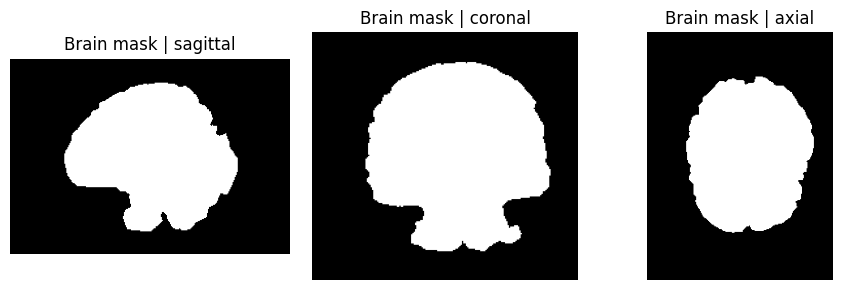

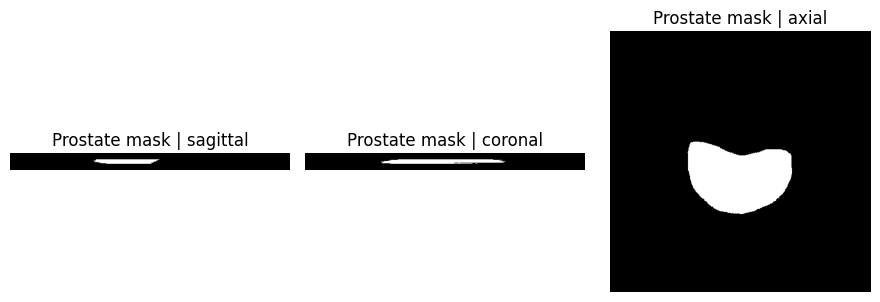

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def show_middle_slices(volume, title: str):
    data = np.asarray(volume.data)
    if data.ndim > 3:
        data = data[..., 0]
    mids = [dim // 2 for dim in data.shape[:3]]
    slices = [
        data[mids[0], :, :],
        data[:, mids[1], :],
        data[:, :, mids[2]],
    ]
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    for ax, slc, axis_label in zip(axes, slices, ("sagittal", "coronal", "axial")):
        ax.imshow(np.rot90(slc), cmap="gray")
        ax.set_title(f"{title} | {axis_label}")
        ax.axis("off")
    fig.tight_layout()
    plt.show()

if brain_volume is not None:
    show_middle_slices(brain_volume, "Brain mask")
if prostate_volume is not None:
    show_middle_slices(prostate_volume, "Prostate mask")

In [17]:
current_example = prostate_volume

### Step 2: Mask preprocessing
Isolate the dominant connected component and fill interior voids so the anatomy mesh stays contiguous.

In [18]:
preprocess_config = gimmeJig.MaskPreprocessConfig(
    binarize_threshold=0.5,
    connectivity=1,
    fill_holes=True,
    take_largest_component=True,
)

mask_result = None
if current_example is None:
    print("Select a volume by assigning `current_example` to a loaded mask.")
else:
    mask_result = gimmeJig.preprocess_mask(current_example, preprocess_config)
    print(f"Original voxels: {mask_result.original_voxel_count:,}")
    print(f"Processed voxels: {mask_result.processed_voxel_count:,}")
    print(f"Components detected: {mask_result.num_components}")
    if mask_result.component_sizes.size:
        top_components = np.sort(mask_result.component_sizes)[::-1][:5]
        formatted = ", ".join(f"{int(size):,}" for size in top_components)
        print(f"Largest components (voxels): {formatted}")
    print(f"Removed voxels from other components: {mask_result.removed_voxels:,}")
    print(f"Holes filled (voxels added): {mask_result.holes_filled_voxels:,}")
    if mask_result.warnings:
        print("Warnings:")
        for message in mask_result.warnings:
            print(f" - {message}")

Original voxels: 157,374
Processed voxels: 157,374
Components detected: 1
Largest components (voxels): 157,374
Removed voxels from other components: 0
Holes filled (voxels added): 0


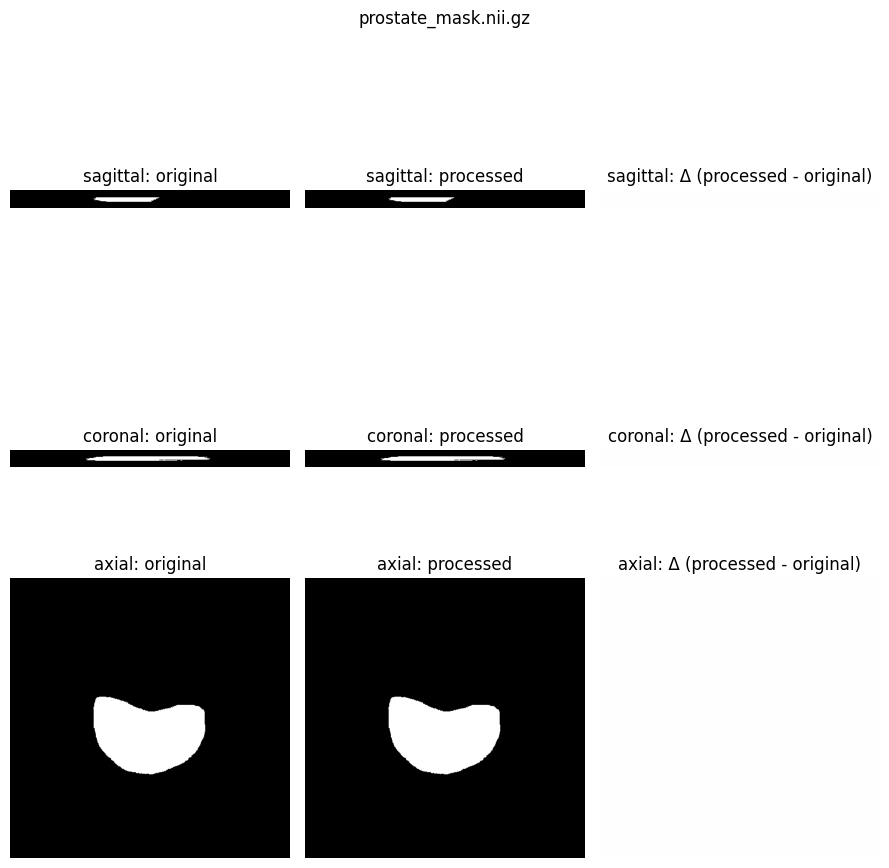

In [20]:
def show_preprocess_comparison(result, title: str):
    if result is None:
        return
    original = result.input_mask.astype(int)
    processed = result.mask.astype(int)
    delta = processed - original
    mids = [dim // 2 for dim in original.shape]
    orientations = ("sagittal", "coronal", "axial")
    slices = [
        (original[mids[0], :, :], processed[mids[0], :, :], delta[mids[0], :, :]),
        (original[:, mids[1], :], processed[:, mids[1], :], delta[:, mids[1], :]),
        (original[:, :, mids[2]], processed[:, :, mids[2]], delta[:, :, mids[2]]),
    ]
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for row, (orientation, slice_triplet) in enumerate(zip(orientations, slices)):
        orig_slice, proc_slice, delta_slice = slice_triplet
        axes[row, 0].imshow(np.rot90(orig_slice), cmap="gray")
        axes[row, 0].set_title(f"{orientation}: original")
        axes[row, 1].imshow(np.rot90(proc_slice), cmap="gray")
        axes[row, 1].set_title(f"{orientation}: processed")
        axes[row, 2].imshow(np.rot90(delta_slice), cmap="bwr", vmin=-1, vmax=1)
        axes[row, 2].set_title(f"{orientation}: Δ (processed - original)")
    for ax in axes.flat:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

if mask_result is not None:
    name = getattr(current_example, "path", None)
    title = name.name if name is not None else "Selected volume"
    show_preprocess_comparison(mask_result, title)